# Modified Code for VAE processing of ROOT data


**Installs**

In [ ]:
# %pip install uproot


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# %pip install awkward_pandas

In [1]:
##importing libraries##
import os
import numpy as np
import pandas as pd
import uproot

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

import time

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


Loading Root File

In [2]:


ROOT_FILE = "/Users/ruthhodgson/geant4_apps/QEPET/build/out.root"

file = uproot.open(ROOT_FILE)

print(file.keys())
tree = file['ThreeG_NCS']

# for key in file.keys():
#     print(file[key].keys())
print(tree.keys())


['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


Checking Branches and Channels

In [3]:
branches  = [
    'EventID',
    'NGammas', 

    'AnnihilX_mm', 
    'AnnihilY_mm', 
    'AnnihilZ_mm', 
    
    'GammaIndex', 
    'GammaTrackID', 
    'GammaParentID', 
    
    'HitIndex', 
    
    'VolumeID', 
    'VolumeName', 
    'ProcessID', 
    'ProcessName', 
    
    'EnergyDeposit_keV', 
    'PreEnergy_keV', 
    'PostEnergy_keV', 
    
    'X_mm', 
    'Y_mm', 
    'Z_mm', 
    'Theta_deg',
    'Phi_deg', 
    'DeltaPhi01_deg', 
    'DeltaPhi02_deg', 
    'DeltaPhi12_deg']

tree = file["ThreeG_ScannerTCS"]
df = tree.arrays(branches, library="pd")

runs = ['NumberOfEvents, QuantumEntanglement']
run_tree = file['Run']
df_runs = run_tree.arrays(runs)
# print(df_runs)

print(df.head())
# print(df[['EnergyDeposit_keV', 'PreEnergy_keV']].head())

print(
    np.allclose(
        df["EnergyDeposit_keV"],
        df["PreEnergy_keV"]
    )
)

print(
    np.allclose(
        df["PostEnergy_keV"],
        0
    )
)

   EventID  NGammas  AnnihilX_mm  AnnihilY_mm  AnnihilZ_mm  GammaIndex  \
0       13        3     -1.61044     2.047872    -6.897967           0   
1       13        3     -1.61044     2.047872    -6.897967           0   
2       13        3     -1.61044     2.047872    -6.897967           1   
3       13        3     -1.61044     2.047872    -6.897967           1   
4       13        3     -1.61044     2.047872    -6.897967           2   

   GammaTrackID  GammaParentID  HitIndex  VolumeID  ...  PreEnergy_keV  \
0             4              1         0         1  ...     277.131927   
1             4              1         1         1  ...     228.099640   
2             3              1         0         1  ...     358.324677   
3             3              1         1         1  ...     301.740356   
4             2              1         0         1  ...     386.541199   

   PostEnergy_keV       X_mm       Y_mm       Z_mm   Theta_deg     Phi_deg  \
0      228.099640 -27.526379  20

In [4]:
branches  = [
    'EventID',
    'NGammas', 

    'AnnihilX_mm', 
    'AnnihilY_mm', 
    'AnnihilZ_mm', 
    
    'GammaIndex', 
    'GammaTrackID', 
    'GammaParentID', 
    
    'HitIndex', 
    
    'VolumeID', 
    'VolumeName', 
    'ProcessID', 
    'ProcessName', 
    
    'EnergyDeposit_keV', 
    'PreEnergy_keV', 
    'PostEnergy_keV', 
    
    'X_mm', 
    'Y_mm', 
    'Z_mm', 
    'Theta_deg',
    'Phi_deg', 
    'DeltaPhi01_deg', 
    'DeltaPhi02_deg', 
    'DeltaPhi12_deg']

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")

print(df.head())
# print(df[['EnergyDeposit_keV', 'PreEnergy_keV']].head())


print(
    np.allclose(
        df["EnergyDeposit_keV"],
        df["PreEnergy_keV"]
    )
)

print(
    np.allclose(
        df["PostEnergy_keV"],
        0
    )
)

   EventID  NGammas  AnnihilX_mm  AnnihilY_mm  AnnihilZ_mm  GammaIndex  \
0       38        3     3.446918     3.993896    -7.031756           0   
1       38        3     3.446918     3.993896    -7.031756           1   
2       38        3     3.446918     3.993896    -7.031756           2   
3       44        3     4.067925     4.921320    -6.931456           0   
4       44        3     4.067925     4.921320    -6.931456           1   

   GammaTrackID  GammaParentID  HitIndex  VolumeID  ...  PreEnergy_keV  \
0             4              1         0         1  ...     317.166779   
1             3              1         0         1  ...     322.067932   
2             2              1         0         1  ...     382.763092   
3             4              1         0         1  ...     233.156601   
4             3              1         0         1  ...     286.689056   

   PostEnergy_keV       X_mm       Y_mm       Z_mm  Theta_deg  Phi_deg  \
0             0.0 -36.441200  18.452

Checking Detector Hits and Number of Events

In [5]:
print()

print("Number of detector hits =", len(df))

print()

num = file['Run'].arrays('NumberOfEvents') 
print("Number of events =",
      num['NumberOfEvents'])

print()

print(df.describe())


Number of detector hits = 14070

Number of events = [100000]

            EventID  NGammas   AnnihilX_mm   AnnihilY_mm   AnnihilZ_mm  \
count  14070.000000  14070.0  14070.000000  14070.000000  14070.000000   
mean   49998.084222      3.0      1.836121      2.962563     -8.123689   
std    28879.401249      0.0      1.998732      2.601536      1.862211   
min       38.000000      3.0     -3.146044     -2.278039    -13.110999   
25%    24635.000000      3.0      0.264256      0.732249     -9.441192   
50%    50144.000000      3.0      1.858163      2.939867     -8.159641   
75%    74856.000000      3.0      3.410416      5.178928     -6.797307   
max    99806.000000      3.0      6.755358      8.101589     -2.974276   

         GammaIndex  GammaTrackID  GammaParentID  HitIndex  VolumeID  ...  \
count  14070.000000  14070.000000        14070.0   14070.0   14070.0  ...   
mean       1.000000      3.000000            1.0       0.0       1.0  ...   
std        0.816526      0.816526      

Defining Image Size

In [6]:
IMG_SIZE = 64

xmin = df.X_mm.min()
xmax = df.X_mm.max()

ymin = df.Y_mm.min()
ymax = df.Y_mm.max()

zmin = df.Z_mm.min()
zmax = df.Z_mm.max()

print(xmin, xmax)
print(ymin, ymax)
print(zmin, zmax)

-88.86482 91.87003
-89.27776 93.60778
-90.85323 90.785965


In [7]:
print(tree.num_entries)

14070.0


In [9]:
print(df.shape)
print(df["EventID"].nunique())
print(df.groupby(["EventID"]).ngroups)

(14070, 24)
4690
4690


**Building Images for 2D Projections and Regresion Targets**



*   XY
*   XZ
*   YZ




In [10]:

images = []
targets = []

event_groups = df.groupby([ "EventID", "EventID"], sort=False)



print(f"Building images from {event_groups.ngroups} events...")


for i, ((run_id, event_id), event) in enumerate(event_groups):

    # all hits with this RunID and EventID belong to one event

    image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)


    # Channel 0: XY projection

    H_xy, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [ymin, ymax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 0] = H_xy



    # Channel 1: XZ projection

    H_xz, _, _ = np.histogram2d(
        event["X_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 1] = H_xz



    # Channel 2: YZ projection

    H_yz, _, _ = np.histogram2d(
        event["Y_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[ymin, ymax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 2] = H_yz

    # Regression Targets


    annihil_x = event["AnnihilX_mm"].iloc[0]
    annihil_y = event["AnnihilY_mm"].iloc[0]
    annihil_z = event["AnnihilZ_mm"].iloc[0]

    target = [
        annihil_x,
        annihil_y,
        annihil_z,
    ]



    # Store image and target


    images.append(image)
    targets.append(target)


    if (i + 1) % 1000 == 0:
        print(f"{i+1} events processed")


# Convert lists to arrays
images = np.array(images, dtype=np.float16)
targets = np.array(targets, dtype=np.float32)


print()
print("Images shape :", images.shape)
print("Targets shape:", targets.shape)

Building images from 4690 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed

Images shape : (4690, 64, 64, 3)
Targets shape: (4690, 3)


In [12]:
print("Images:", images.shape)
print("Targets:", targets.shape)

print("\nExample target:")
print(targets[0])

Images: (4690, 64, 64, 3)
Targets: (4690, 3)

Example target:
[ 3.446918   3.9938955 -7.031756 ]


In [13]:
images /= np.max(images)

print(images.min())
print(images.max())

0.0
1.0


In [14]:
print("Images shape:", images.shape)
print("Targets shape:", targets.shape)

print("\nFirst target:")
print(targets[0])

Images shape: (4690, 64, 64, 3)
Targets shape: (4690, 3)

First target:
[ 3.446918   3.9938955 -7.031756 ]


** Train-Test Split for Model**

In [15]:
from sklearn.model_selection import train_test_split

batch_size = 64

X_train, X_test, y_train, y_test = train_test_split(
    images,
    targets,
    test_size=0.2,
    random_state=42
)

train_dataset = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(len(X_train))
    .batch(batch_size)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices(X_test)
    .batch(batch_size)
)

print("X Training images:", X_train.shape)
print("X Testing images:", X_test.shape)

print("Y Training targets:", y_train.shape)
print("Y Testing targets:", y_test.shape)

X Training images: (3752, 64, 64, 3)
X Testing images: (938, 64, 64, 3)
Y Training targets: (3752, 3)
Y Testing targets: (938, 3)


**Standard Scaler**

In [16]:
from sklearn.preprocessing import StandardScaler


target_scaler = StandardScaler()


y_train_scaled = target_scaler.fit_transform(y_train)

y_test_scaled = target_scaler.transform(y_test)

print(y_train_scaled[0])

[ 0.43342704  0.43846714 -1.2158053 ]


**VAE Model Building - Encoder**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)
class ConVAE(tf.keras.Model):

    def __init__(self, latent_dim):
        super(ConVAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = tf.keras.Sequential(
            [
                tf.keras.layers.InputLayer(input_shape = (64, 64, 3)), 
                tf.keras.layers.Conv2D(filters = 32, kernel_size=3, strides = (2,2), activation = 'relu'),
                tf.keras.layers.Conv2D(filters = 64, kernel_size=3, strides = (2,2), activation = 'relu'),
                tf.keras.layers.Flatten(), #this layer doens't have an activation
                tf.keras.layers.Dense(latent_dim + latent_dim) # 2x as we have two params per dim
            ]
        )

        self.decoder = tf.keras.Sequential(
            [
                tf.keras.layers.InputLayer(input_shape = (latent_dim,)),#the latent dims are decided by us, this is the output of the encoder and so the input of the decoder
                tf.keras.layers.Dense(units = 16*16*64, activation = 'relu'),
                tf.keras.layers.Reshape(target_shape=(16,16,64)),
                tf.keras.layers.Conv2DTranspose(filters = 64, kernel_size = 3, strides=2, padding = 'same', activation = 'relu'),
                tf.keras.layers.Conv2DTranspose(filters = 32, kernel_size = 3, strides=2, padding = 'same', activation = 'relu'),
                tf.keras.layers.Conv2DTranspose(filters = 3, kernel_size = 3, strides = 1, padding='same'),
            ]
        )
    @tf.function
    def sample(self,eps=None):#eps is the radom noise
        if eps is None:
            eps = tf.random.normal(shape = (100, self.latent_dim))
        return self.decode(eps, apply_sigmoid = True)
    
    def encode(self, image):
        mean, logvar = tf.split(self.encoder(image), num_or_size_splits = 2, axis = 1)
        return mean, logvar

    def reparam(self, mean, logvar): #this returns z essentially from the mu, omega and epsilon
        eps = tf.random.normal(shape = mean.shape)
        return eps * tf.exp(logvar*0.5) + mean
    
    def decode(self, z, apply_sigmoid = False):
        logits = self.decoder(z)
        if apply_sigmoid:
            probs = tf.sigmoid(logits)
            return probs
        return logits
    



**Defining the Loss Function**

In [67]:
## loss function
learning_rate = 1e-4
optim = tf.keras.optimizers.Adam(learning_rate)

##define the logarithim of the pdf, here we use a normal dist

def log_pdf_norm(sample_z, mean, logvar, raxis = 1):
    log2pi = tf.math.log(2.*np.pi)
    return tf.reduce_sum(
        -0.5 * ((sample_z - mean)**2. * tf.exp(-logvar) + logvar + log2pi), axis = raxis
    )


def loss_func(model, image):
    image = tf.cast(image, tf.float32)
    mean, logvar = model.encode(image)
    z = model.reparam(mean, logvar)
    x_logit = model.decode(z)
    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits = x_logit, labels = image)
    log_p_im_z = -tf.reduce_sum(cross_ent, axis = [1,2,3])
    log_p_z = log_pdf_norm(z,0.,0.)
    log_q_z_im = log_pdf_norm(z, mean, logvar)
    
    return -tf.reduce_mean(log_p_im_z+log_p_z-log_q_z_im)

@tf.function
def training_vae(model, image, vae_optim):
    with tf.GradientTape() as tape:
        vae_loss = loss_func(model, image)
    vae_gradients = tape.gradient(vae_loss, model.trainable_variables)
    optim.apply_gradients(zip(vae_gradients, model.trainable_variables))




**Getting our latent space z**

In [55]:
epochs = 10
latent_dim = 2 #for now
num_examples = 16

random_vector = tf.random.normal(shape=[num_examples, latent_dim])

model = ConVAE(latent_dim)
            

**Producing a predictor to obtain a predicted y from the latent space**

In [ ]:
# def visuals(model, epoch, test_sample):
#     mean, logvar = model.encode(test_sample)
#     # z = model.reparam(mean, logvar)
#     latents = model.sample(z)
    
#     fig = plt.figure(figsize = (4,4))

#     for i in range(latents.shape[0]):
#         plt.subplot(4,4,i+1)
#         plt.imshow(latents[i, :, :, 0],cmap=  'gray')
#         plt.axis('off')

#     plt.show()
#     plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))


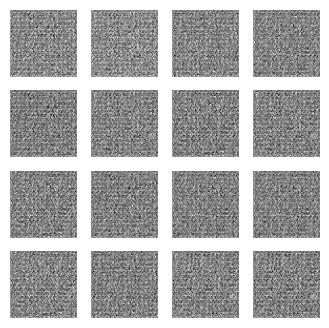

Epoch: 1, Test set ELBO: -7703.7041015625, time elapse for current epoch: 11.069369077682495
Epoch: 2, Test set ELBO: -897.5587158203125, time elapse for current epoch: 9.726247787475586
Epoch: 3, Test set ELBO: -454.2222595214844, time elapse for current epoch: 8.553110122680664
Epoch: 4, Test set ELBO: -284.6414794921875, time elapse for current epoch: 8.69825267791748
Epoch: 5, Test set ELBO: -191.52682495117188, time elapse for current epoch: 9.693328142166138
Epoch: 6, Test set ELBO: -142.8432159423828, time elapse for current epoch: 11.050294876098633
Epoch: 7, Test set ELBO: -111.11534118652344, time elapse for current epoch: 10.015835046768188
Epoch: 8, Test set ELBO: -92.32127380371094, time elapse for current epoch: 9.239933967590332
Epoch: 9, Test set ELBO: -80.60671997070312, time elapse for current epoch: 9.63476300239563
Epoch: 10, Test set ELBO: -70.61201477050781, time elapse for current epoch: 10.574549913406372


<Figure size 640x480 with 0 Axes>

In [68]:


for epoch in range(1, epochs + 1):
    start_t = time.time()
    for train_x in train_dataset:
        training_vae(model, train_x, optim)
    end_t = time.time()

    loss = tf.keras.metrics.Mean()
    for test_x in test_dataset:
        loss(loss_func(model, test_x))
    elbo = -loss.result()
    # clear_output(wait=False)
    print(f'Epoch: {epoch}, Test set ELBO: {elbo}, time elapse for current epoch: {end_t - start_t}')
    

    

In [82]:
print(X_train.shape)
print(y_train_scaled.shape)
print(type(X_train))
print(type(y_train_scaled))

(3752, 64, 64, 3)
(3752, 3)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [83]:
predict = tf.keras.Sequential(
        [tf.keras.layers.Input(shape=(latent_dim,)),
         tf.keras.layers.Dense(128, activation = 'relu'),
         tf.keras.layers.Dropout(0.3),
         tf.keras.layers.Dense(3)]
)
#obtain z from the vae to be used in the predictor training and train

target = tf.cast(target, tf.float32)

prediction_data = tf.data.Dataset.from_tensor_slices((X_train, y_train_scaled))

@tf.function
def training_predict(predict, z, target, pred_optim):
    with tf.GradientTape() as tape:
        prediction = predict(z)
        pred_loss = tf.reduce_mean(tf.square(prediction-target))
    pred_grad =tape.gradient(pred_loss, predict.trainable_variables )
    pred_optim.apply_gradients(zip(pred_grad, predict.trainable_variables))
    return pred_loss, prediction


In [84]:
#running the predictor trainer

for epoch in range(1, epochs+1):
    for image, target in prediction_data:
        mean, logvar = model.encode(image)
        z = model.reparam(mean, logvar)

        pred_loss = training_predict(predict, z, target, pred_optim)

    print(f"Epoch: {epoch}, Prediction loss: {pred_loss.numpy()}")

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input [[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]] with name 'keras_tensor_33' and path ''. Expected shape (None, 64, 64, 3), but input has incompatible shape (64, 64, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(64, 64, 3), dtype=float32)
  • training=None
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [72]:
model.summary()

model.compile(
    optimizer="adam",
    loss='mse',
    metrics=["mae", 'accuracy']
)

Model: "con_vae_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 4)              │        76,996 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 64, 64, 3)      │       105,411 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,407 (712.53 KB)

 Trainable params: 182,407 (712.53 KB)

 Non-trainable params: 0 (0.00 B)

**Test Accuracy, loss and MAE**

In [74]:
test_loss, test_mae, test_accuracy = model.evaluate(
    X_test,
    y_test_scaled
)

print("Test loss:", test_loss)
print("Test MAE:", test_mae)
print("Test accuracy:", test_accuracy)

NotImplementedError: Exception encountered when calling ConVAE.call().

[1mModel ConVAE does not have a `call()` method implemented.[0m

Arguments received by ConVAE.call():
  • args=('tf.Tensor(shape=(None, 64, 64, 3), dtype=float32)',)
  • kwargs=<class 'inspect._empty'>

In [75]:
prediction_scaled = model.predict(X_test)

prediction = target_scaler.inverse_transform(prediction_scaled)

NotImplementedError: Exception encountered when calling ConVAE.call().

[1mModel ConVAE does not have a `call()` method implemented.[0m

Arguments received by ConVAE.call():
  • args=('tf.Tensor(shape=(32, 64, 64, 3), dtype=float32)',)
  • kwargs=<class 'inspect._empty'>

In [30]:
for i in range(5):
    print("True:     ", y_test[i])
    print("Predicted:", prediction[i])
    print()

True:      [-0.47320542  4.2953987  -7.0890417 ]
Predicted: [ 0.8208379  4.286647  -6.3383794]

True:      [-1.8619603  4.479793  -6.924948 ]
Predicted: [ 3.1684759  3.9404233 -8.490672 ]

True:      [ 2.2345228  1.8696158 -8.54246  ]
Predicted: [ 0.8138564  3.4657984 -7.354365 ]

True:      [ 1.3888016   0.11342431 -6.7022667 ]
Predicted: [ 1.4514536  3.4801059 -7.4423995]

True:      [ 3.8511534  2.3501887 -9.376963 ]
Predicted: [ 3.5399342  2.5194967 -9.568745 ]



**Position Error**

In [31]:
position_error = prediction[:,:3] - y_test[:,:3]


distance_error = np.sqrt(
    position_error[:,0]**2 +
    position_error[:,1]**2 +
    position_error[:,2]**2
)


print(
    "Mean annihilation position error:",
    np.mean(distance_error),
    "mm"
)

Mean annihilation position error: 2.6766298 mm


** Reconstruction for X,Y,Z Annihilation - True vs Predicted **

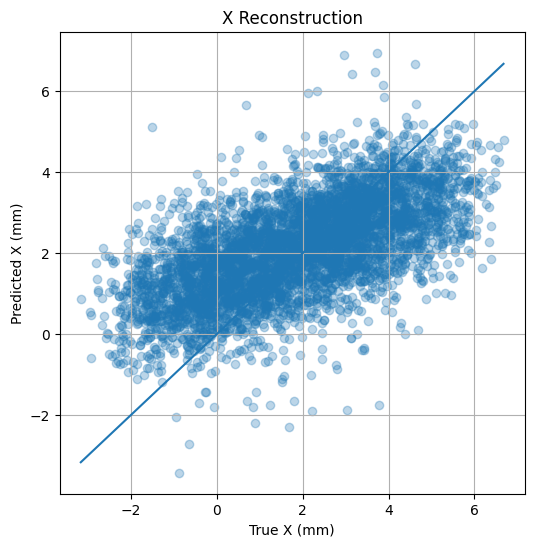

In [32]:
# X
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,0],
    prediction[:,0],
    alpha=0.3
)

plt.xlabel("True X (mm)")
plt.ylabel("Predicted X (mm)")
plt.title("X Reconstruction")

plt.plot(
    [y_test[:,0].min(), y_test[:,0].max()],
    [y_test[:,0].min(), y_test[:,0].max()]
)

plt.grid()
plt.show()

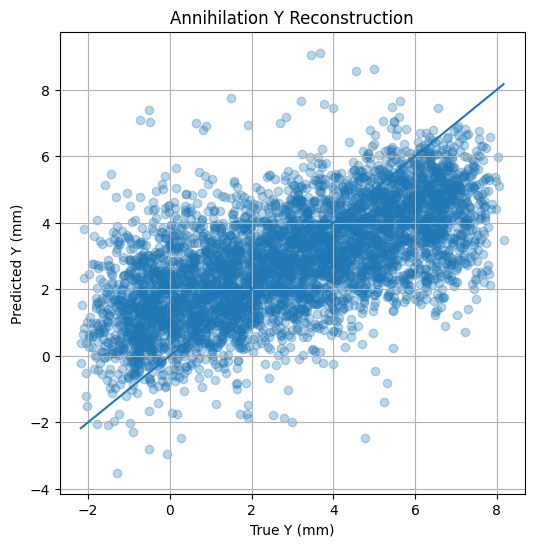

In [33]:
#Y
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,1],          # True Y
    prediction[:,1],      # Predicted Y
    alpha=0.3
)

plt.xlabel("True Y (mm)")
plt.ylabel("Predicted Y (mm)")

plt.title("Annihilation Y Reconstruction")


plt.plot(
    [y_test[:,1].min(), y_test[:,1].max()],
    [y_test[:,1].min(), y_test[:,1].max()]
)

plt.grid()
plt.show()

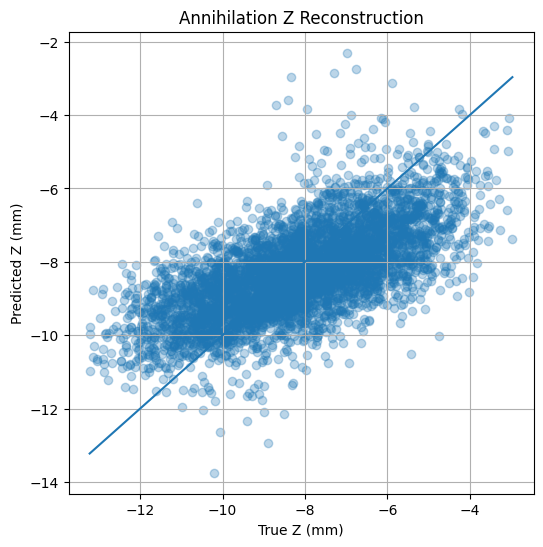

In [34]:
#Z
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,2],          # True Z
    prediction[:,2],      # Predicted Z
    alpha=0.3
)

plt.xlabel("True Z (mm)")
plt.ylabel("Predicted Z (mm)")

plt.title("Annihilation Z Reconstruction")


plt.plot(
    [y_test[:,2].min(), y_test[:,2].max()],
    [y_test[:,2].min(), y_test[:,2].max()]
)

plt.grid()
plt.show()

**Comparing to a baseline that is just guessing in the 'middle' position**

In [35]:
# comparing to baseline
mean_position = np.mean(y_train, axis=0)

print(mean_position)
baseline_prediction = np.tile(
    mean_position,
    (len(y_test),1)
)

from sklearn.metrics import mean_squared_error

baseline_mse = mean_squared_error(
    y_test,
    baseline_prediction
)

cnn_mse = mean_squared_error(
    y_test,
    prediction
)

print("Baseline MSE:", baseline_mse)
print("CNN MSE:", cnn_mse)

[ 1.8453559  2.9287858 -8.15671  ]
Baseline MSE: 4.707585334777832
CNN MSE: 2.8345258235931396


In [36]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

cnn_mae = mean_absolute_error(
    y_test,
    prediction
)

print("Baseline MAE:", baseline_mae)
print("CNN MAE:", cnn_mae)

Baseline MAE: 1.8075875043869019
CNN MAE: 1.3306385278701782


In [29]:
print("True X,Y,Z standard deviation:")
print(np.std(y_test, axis=0))

print("\nPredicted X,Y,Z standard deviation:")
print(np.std(prediction, axis=0))

True X,Y,Z standard deviation:
[1.9862987 2.5641627 1.897851 ]

Predicted X,Y,Z standard deviation:
[1.2061489 1.4534307 1.1881562]


In [37]:
#comparing x,y,z separately
for i, coord in enumerate(["X","Y","Z"]):

    baseline = mean_absolute_error(
        y_test[:,i],
        baseline_prediction[:,i]
    )

    cnn = mean_absolute_error(
        y_test[:,i],
        prediction[:,i]
    )

    print(coord)
    print("Baseline:", baseline)
    print("CNN:", cnn)
    print()

X
Baseline: 1.6673718690872192
CNN: 1.2560198307037354

Y
Baseline: 2.207219362258911
CNN: 1.586666226387024

Z
Baseline: 1.5481683015823364
CNN: 1.1492282152175903



In [45]:
from sklearn.metrics import r2_score

print("Overall R²:", r2_score(y_test, prediction))

print("X R²:", r2_score(y_test[:,0], prediction[:,0]))
print("Y R²:", r2_score(y_test[:,1], prediction[:,1]))
print("Z R²:", r2_score(y_test[:,2], prediction[:,2]))

Overall R²: 0.39816442131996155
X R²: 0.3706376552581787
Y R²: 0.3998764157295227
Z R²: 0.4239771366119385


**Plotting True and Predicted X,YZ co-ords**

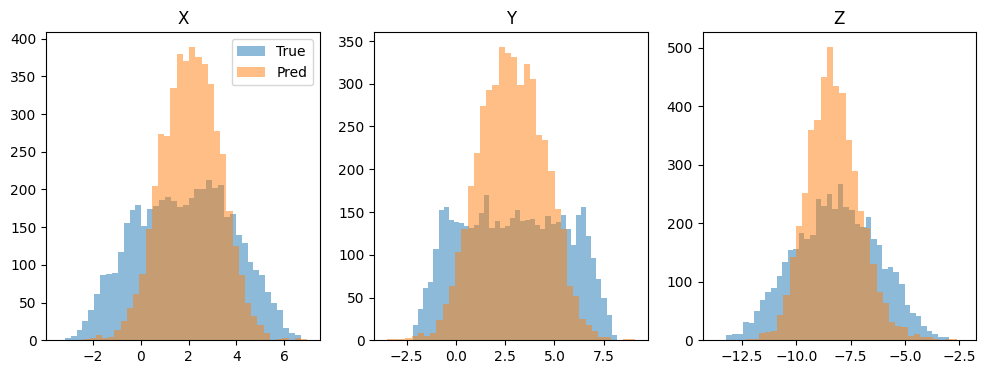

In [38]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(y_test[:,0], bins=40, alpha=0.5, label="True")
plt.hist(prediction[:,0], bins=40, alpha=0.5, label="Pred")
plt.title("X")

plt.legend()

plt.subplot(1,3,2)
plt.hist(y_test[:,1], bins=40, alpha=0.5)
plt.hist(prediction[:,1], bins=40, alpha=0.5)
plt.title("Y")

plt.subplot(1,3,3)
plt.hist(y_test[:,2], bins=40, alpha=0.5)
plt.hist(prediction[:,2], bins=40, alpha=0.5)
plt.title("Z")

plt.show()

**Plotting Residuals - Difference between CNN model and True Annihilation Positions**

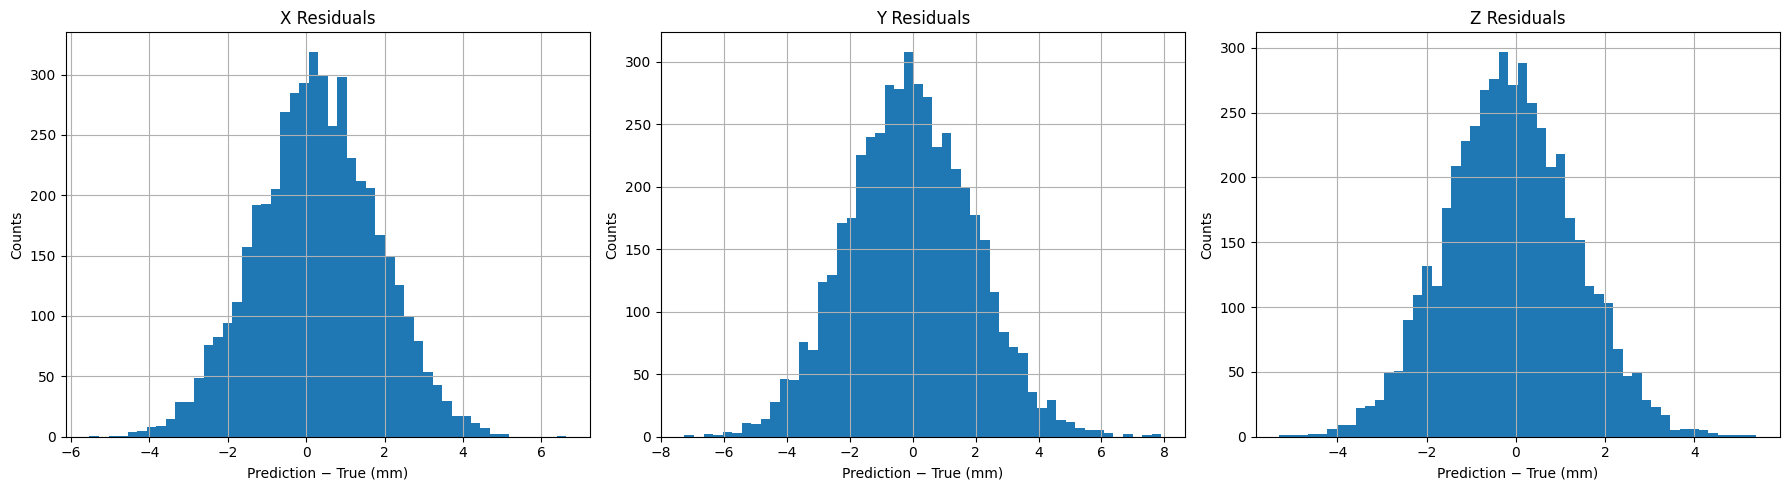

In [40]:
residuals = prediction - y_test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):

    ax.hist(
        residuals[:, i],
        bins=50
    )

    ax.set_title(f"{coords[i]} Residuals")
    ax.set_xlabel("Prediction − True (mm)")
    ax.set_ylabel("Counts")
    ax.grid(True)

plt.tight_layout()
plt.show()


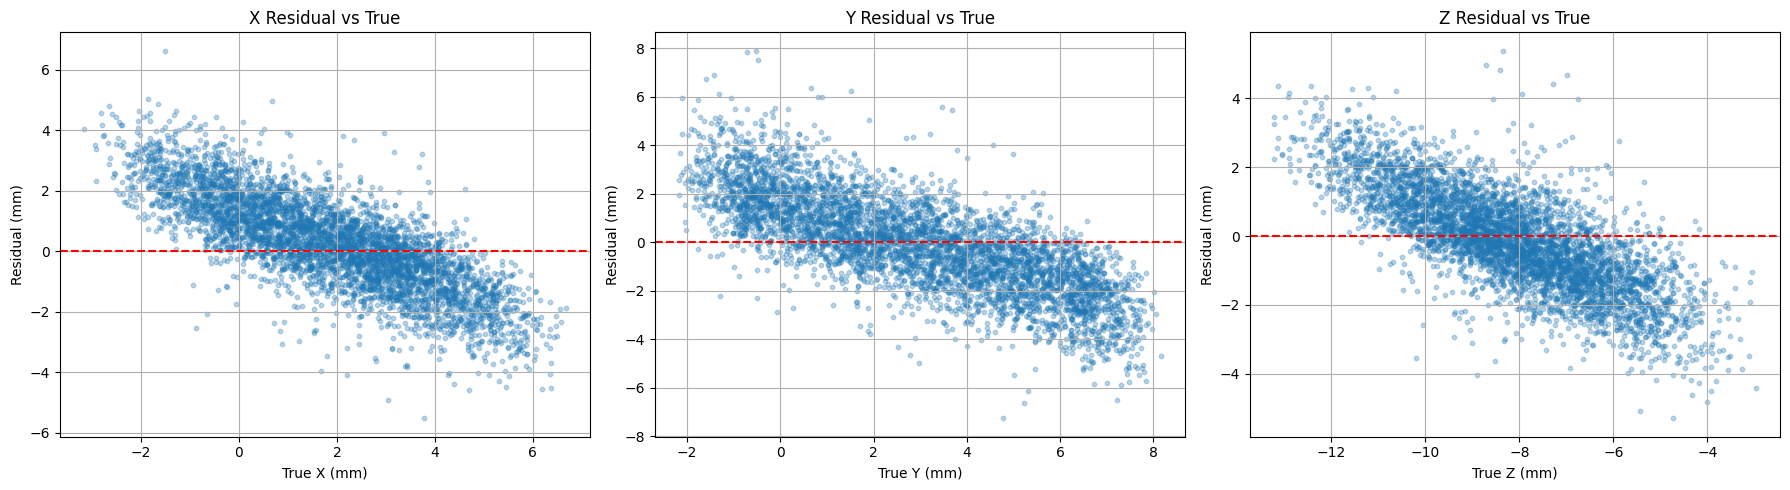

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):

    ax.scatter(
        y_test[:, i],
        residuals[:, i],
        alpha=0.3,
        s=10
    )

    ax.axhline(
        0,
        color="red",
        linestyle="--"
    )

    ax.set_xlabel(f"True {coords[i]} (mm)")
    ax.set_ylabel("Residual (mm)")
    ax.set_title(f"{coords[i]} Residual vs True")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [42]:
coords = ["X", "Y", "Z"]

for i in range(3):

    print(f"{coords[i]}")

    print(f"Mean residual: {np.mean(residuals[:,i]):.2f} mm")
    print(f"Std residual : {np.std(residuals[:,i]):.2f} mm")
    print(f"MAE          : {np.mean(np.abs(residuals[:,i])):.2f} mm")

    print()

X
Mean residual: 0.27 mm
Std residual : 1.55 mm
MAE          : 1.26 mm

Y
Mean residual: -0.07 mm
Std residual : 1.99 mm
MAE          : 1.59 mm

Z
Mean residual: -0.12 mm
Std residual : 1.44 mm
MAE          : 1.15 mm

